# L19 · Flow Matching and a Minimal Diffusion Model

*Companion notebook for Lecture 19 — Diffusion and Flow Matching (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Compute the exact marginal velocity field of a tiny 1-D problem and follow it with Euler steps (the lecture's worked example).
2. Train a velocity MLP $\mathbf v_\theta(\mathbf x_t, t)$ by **conditional flow matching** on 2-D data, and understand why its loss plateaus far above zero.
3. Generate samples by integrating $d\mathbf x/dt = \mathbf v_\theta$ from $t = 1$ (noise) to $t = 0$ (data); visualize trajectories and the velocity field.
4. Train a minimal **DDPM** (noise prediction) on the same data and compare sample quality versus the number of sampling steps with the sliced Wasserstein distance.
5. (Optional, GPU) Train a class-conditional flow-matching model on BloodMNIST images with classifier-free guidance.

**Time convention (as in the slides):** $t = 0$ is data, $t = 1$ is noise. Linear path $\mathbf x_t = (1-t)\,\mathbf x_0 + t\,\boldsymbol\epsilon$, target velocity $\boldsymbol\epsilon - \mathbf x_0$; DDPM path $\mathbf x_t = \sqrt{\bar\alpha_t}\,\mathbf x_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon$.

Runtime: about 4–5 minutes on a 4-thread CPU (two MLPs × 8,000 Adam steps take most of it). The toy models always train on the CPU, so the numbers are reproducible. The optional BloodMNIST section runs only when a GPU (CUDA or Apple MPS) is found (about 4 minutes on one NVIDIA GPU; the executed copy of this notebook includes it).

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import make_moons
from course_utils import seed_everything, plot_style, device, DATA, PALETTE

rng = seed_everything(0)
plot_style()
torch.set_num_threads(4)
T0 = time.time()

STEPS = 8000         # Adam steps per model, as in the lecture (~70 s per model on a 4-thread CPU)
BATCH = 1024
T_DDPM = 1000        # DDPM steps (Ho et al. 2020: T = 1000, beta 1e-4 -> 0.02)
dev = device()
RUN_BLOOD = dev.type != "cpu"   # optional class-conditional BloodMNIST section (GPU / MPS only)
print("device for the optional image section:", dev, "| run it:", RUN_BLOOD)
C_DATA, C_NOISE, C_FM, C_DDPM, GREY = PALETTE[0], PALETTE[1], PALETTE[0], PALETTE[5], "#9AA5B1"

device for the optional image section: cuda | run it: True


## 1. Dataset

**Why toy data?** Diffusion and flow-matching models generate protein backbones (RFdiffusion), 3-D molecules, the atom coordinates in AlphaFold 3, and medical images. Those models are large, but the *algorithm* is exactly the one in this notebook. In 2-D we can see every sample, draw the velocity field, and measure how close the generated distribution is to the real one — none of which is possible in 10⁵ dimensions.

- **Data:** "two moons", 2-D points on two interleaved half circles with Gaussian noise (SD 0.06), from `sklearn.datasets.make_moons` (scikit-learn, BSD-3 license; synthetic, no patient data). Think of it as a stand-in for a data distribution with two separated, curved modes — e.g. two cell states in a 2-D embedding.
- **One sample** = one point $\mathbf x_0 \in \mathbb R^2$; the label (which moon) is used only for the optional class-conditional part.
- **Goal:** learn to turn Gaussian noise $\boldsymbol\epsilon \sim \mathcal N(\mathbf 0, \mathbf I)$ into new samples from $p_\text{data}$.
- **Optional:** BloodMNIST (MedMNIST v2, Yang et al., *Sci. Data* 10, 41, 2023; CC BY 4.0), 3 × 28 × 28 images of blood cells in 8 classes (see L09).

**Preprocessing.** The moons are centered and rescaled to roughly unit scale, so that data and noise have comparable spread (the same function as in the lecture). Training draws minibatches of 1,024 from a pool of 50,000 points.

In [2]:
def moons(n, seed, labels=False):
    X, y = make_moons(n, noise=0.06, random_state=seed)
    X = (X - np.array([0.5, 0.25])) / np.array([0.87, 0.5]) * 0.9   # roughly unit scale, centered
    X = X.astype(np.float32)
    return (X, y) if labels else X

X_show, y_show = moons(2000, seed=3, labels=True)
print("mean", X_show.mean(0).round(2), " SD", X_show.std(0).round(2))

def clean(ax, lim=3.0):
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color("#D5DBE3")

mean [ 0. -0.]  SD [0.9  0.89]


## 2. Exploration: data, noise, and the two noising paths

Both families define a path from data ($t = 0$) to noise ($t = 1$) in closed form. DDPM uses $\bar\alpha_t = \prod_{k \le tT}(1-\beta_k)$ with $\beta$ linear from $10^{-4}$ to $0.02$ over $T = 1000$ steps; flow matching uses the straight line. Same data and same noise in each row.

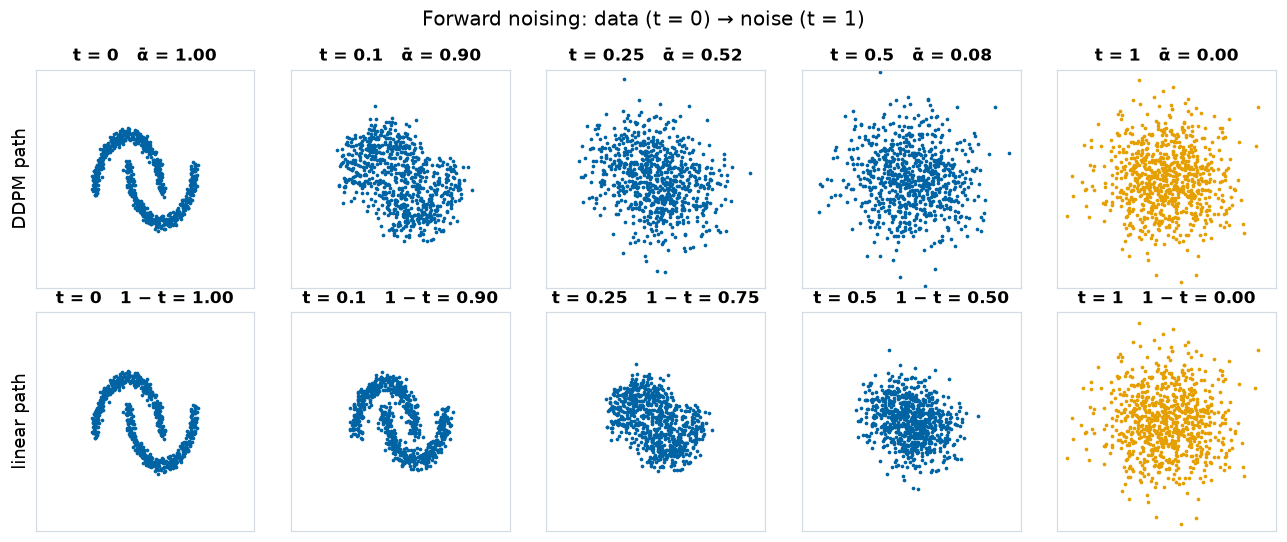

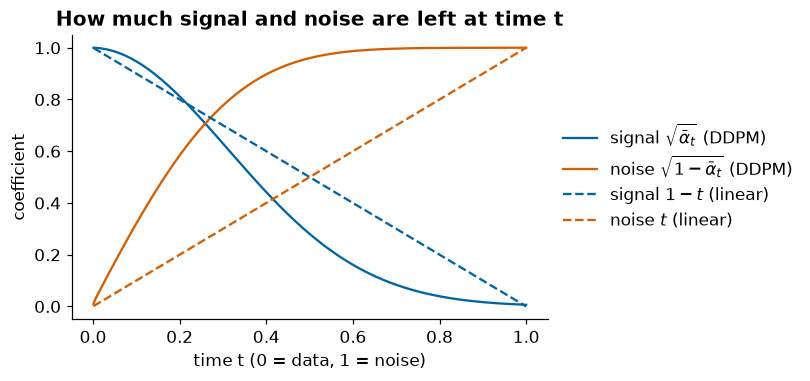

DDPM: ᾱ at t = 0.5 is 0.079, at t = 1 is 4.0e-05  (the DDPM path destroys the signal early)


In [3]:
def ddpm_schedule(T=T_DDPM):
    beta = np.linspace(1e-4, 0.02, T)
    alpha = 1 - beta
    return beta, alpha, np.cumprod(alpha)

_, _, abar = ddpm_schedule()
X0 = moons(800, seed=1)
E = np.random.default_rng(0).normal(size=X0.shape)
ts = [0, 0.1, 0.25, 0.5, 1.0]
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for j, t in enumerate(ts):
    ab = 1.0 if t == 0 else abar[int(round(t * T_DDPM)) - 1]
    for i, (X, lab) in enumerate([(np.sqrt(ab) * X0 + np.sqrt(1 - ab) * E, f"ᾱ = {ab:.2f}"),
                                  ((1 - t) * X0 + t * E, f"1 − t = {1 - t:.2f}")]):
        axs[i, j].scatter(*X.T, s=2, color=C_DATA if t < 1 else C_NOISE)
        axs[i, j].set_title(f"t = {t:g}   {lab}", fontsize=11)
        clean(axs[i, j], 3.4)
axs[0, 0].set_ylabel("DDPM path", fontsize=12); axs[1, 0].set_ylabel("linear path", fontsize=12)
fig.suptitle("Forward noising: data (t = 0) → noise (t = 1)"); plt.tight_layout(); plt.show()

t_grid = np.arange(1, T_DDPM + 1) / T_DDPM
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(t_grid, np.sqrt(abar), color=PALETTE[0], label=r"signal $\sqrt{\bar\alpha_t}$ (DDPM)")
ax.plot(t_grid, np.sqrt(1 - abar), color=PALETTE[5], label=r"noise $\sqrt{1-\bar\alpha_t}$ (DDPM)")
ax.plot(t_grid, 1 - t_grid, color=PALETTE[0], ls="--", label=r"signal $1-t$ (linear)")
ax.plot(t_grid, t_grid, color=PALETTE[5], ls="--", label=r"noise $t$ (linear)")
ax.set(xlabel="time t (0 = data, 1 = noise)", ylabel="coefficient", title="How much signal and noise are left at time t")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.tight_layout(); plt.show()
print(f"DDPM: ᾱ at t = 0.5 is {abar[499]:.3f}, at t = 1 is {abar[-1]:.1e}  (the DDPM path destroys the signal early)")

## 3. What the network must learn: the exact marginal velocity in 1-D

Before training anything, take data that are two point masses, $x_0 \in \{-1, +1\}$ with equal probability. For the linear path, the network's ideal output is the **marginal velocity**
$$u_t(x) = \mathbb E[\epsilon - x_0 \mid x_t = x] = \sum_a P(x_0 = a \mid x_t = x)\,\frac{x - a}{t},\qquad P(x_0 = a \mid x_t = x) \propto \mathcal N\big(x;\,(1-t)a,\,t^2\big).$$
It is a posterior-weighted average of the straight-line (conditional) velocities. The function below computes it exactly (also for data that are narrow Gaussians of SD $s_0$ around each point).

In [4]:
A1 = np.array([-1.0, 1.0])       # two data points, equal weight

def v_marginal_1d(x, t, a=A1, s0=0.0):
    """Exact u_t(x) = E[eps - x0 | x_t = x] for the linear path, p_data = equal mixture of N(a_k, s0^2)."""
    x = np.asarray(x, float)[..., None]
    V = (1 - t) ** 2 * s0 ** 2 + t ** 2
    r = x - (1 - t) * a
    logw = -0.5 * r ** 2 / V
    w = np.exp(logw - logw.max(-1, keepdims=True))
    w /= w.sum(-1, keepdims=True)
    e_eps = t / V * r
    e_x0 = a + (1 - t) * s0 ** 2 / V * r
    return (w * (e_eps - e_x0)).sum(-1), w

xq, tq = 0.5, 0.5
vq, wq = v_marginal_1d(xq, tq)
print(f"query x = {xq}, t = {tq}")
print(f"posterior weights: a = +1: {wq[1]:.3f}   a = -1: {wq[0]:.3f}")
print(f"conditional velocities (x - a)/t: {(xq - 1) / tq:g} and {(xq + 1) / tq:g}")
print(f"marginal velocity u_t(x) = {float(vq):.3f}   (negative: the sample moves up toward +1 as t decreases)")

# Four Euler steps from x_1 = 0.3:  x <- x + (t_next - t) v(x, t) = x - 0.25 v
x, rows = 0.3, []
tt = np.linspace(1, 0, 5)
print("\nstep   t     x_t     v(x_t, t)   x after step")
for i, (t, tn) in enumerate(zip(tt[:-1], tt[1:])):
    v = float(v_marginal_1d(x, t)[0])
    rows.append((t, x))
    print(f"{i + 1:4d}  {t:.2f}  {x:6.3f}   {v:+.3f}      {x + (tn - t) * v:.3f}")
    x = x + (tn - t) * v
rows.append((0.0, x))
print(f"ends at {x:.3f}, next to the data point +1")

query x = 0.5, t = 0.5
posterior weights: a = +1: 0.881   a = -1: 0.119
conditional velocities (x - a)/t: -1 and 3
marginal velocity u_t(x) = -0.523   (negative: the sample moves up toward +1 as t decreases)

step   t     x_t     v(x_t, t)   x after step
   1  1.00   0.300   +0.300      0.225
   2  0.75   0.225   +0.167      0.183
   3  0.50   0.183   -0.335      0.267
   4  0.25   0.267   -2.919      0.997
ends at 0.997, next to the data point +1


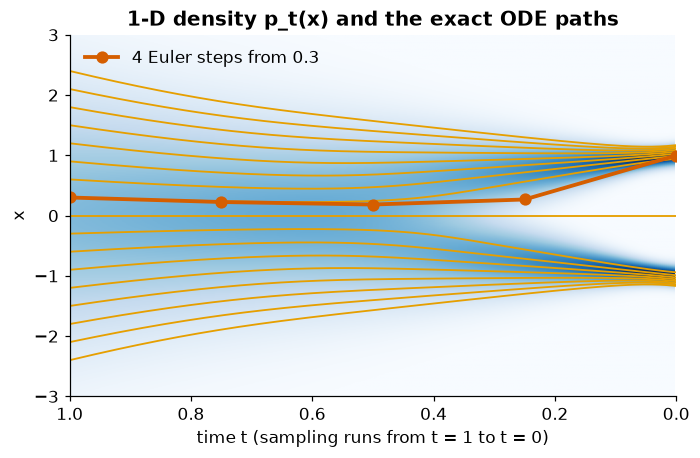

In [5]:
def density_1d(xg, t, a=A1, s0=0.08):
    V = (1 - t) ** 2 * s0 ** 2 + t ** 2
    return np.mean([np.exp(-0.5 * (xg - (1 - t) * ak) ** 2 / V) / np.sqrt(2 * np.pi * V) for ak in a], 0)

xg, tg = np.linspace(-3, 3, 400), np.linspace(0.002, 1, 300)
D = np.array([density_1d(xg, t) for t in tg])
ts_ode = np.linspace(1, 0, 401)
xs = [np.linspace(-2.4, 2.4, 17)]
for t, tn in zip(ts_ode[:-1], ts_ode[1:]):
    xs.append(xs[-1] + (tn - t) * v_marginal_1d(xs[-1], t, s0=0.08)[0])
xs = np.array(xs)
fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.imshow(np.sqrt(D.T), extent=[tg[0], 1, -3, 3], origin="lower", aspect="auto", cmap="Blues", vmax=np.sqrt(D[5:].max()) * 0.9)
for j in range(xs.shape[1]):
    ax.plot(ts_ode, xs[:, j], color=PALETTE[1], lw=1.2)
ax.plot(*zip(*rows), "o-", color=PALETTE[5], lw=2.5, ms=7, label="4 Euler steps from 0.3")
ax.set(xlim=(1, 0), ylim=(-3, 3), xlabel="time t (sampling runs from t = 1 to t = 0)", ylabel="x",
       title="1-D density p_t(x) and the exact ODE paths")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

The first steps barely move: at large $t$ both data points are plausible and the field is weak. The last step does almost all the work — with only 4 steps the path is crude, which in 2-D shows up as blurred samples (Section 7).

## 4. Model: a small MLP for $\mathbf v_\theta(\mathbf x, t)$ or $\boldsymbol\epsilon_\theta(\mathbf x, t)$

Input: $\mathbf x \in \mathbb R^2$ plus 16 sinusoidal features of $t$ ($\sin k\pi t$, $\cos k\pi t$, $k = 1..8$), optionally a class embedding. Three hidden layers of 256 SiLU units, output in $\mathbb R^2$. The same architecture serves as the flow-matching velocity network and as the DDPM noise predictor.

In [6]:
USE_TIME = True      # Try it yourself: set False to remove the time input t (then retrain)

def make_net(n_cls=0, hidden=256, use_time=None):
    use_time = USE_TIME if use_time is None else use_time

    class Net(nn.Module):
        """v_theta(x, t [, c]): x in R^2, t in [0, 1] via sinusoidal features, optional class embedding."""
        def __init__(self):
            super().__init__()
            self.register_buffer("freqs", torch.arange(1, 9).float() * np.pi, persistent=False)
            d_in = 2 + 16 + (16 if n_cls else 0)
            self.emb = nn.Embedding(n_cls + 1, 16) if n_cls else None    # last index = "no class" (for CFG)
            self.f = nn.Sequential(nn.Linear(d_in, hidden), nn.SiLU(), nn.Linear(hidden, hidden), nn.SiLU(),
                                   nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 2))

        def forward(self, x, t, c=None):
            tt = t.reshape(-1, 1) * self.freqs
            if not use_time:
                tt = torch.zeros_like(tt)          # the network no longer knows the time
            h = [x, torch.sin(tt), torch.cos(tt)]
            if self.emb is not None:
                h.append(self.emb(c))
            return self.f(torch.cat(h, 1))
    return Net()

n_par = sum(p.numel() for p in make_net().parameters())
print(f"parameters: {n_par:,}")

parameters: 136,962


## 5. Training: flow matching and DDPM are both plain regressions

**Flow matching** (per minibatch): draw $\mathbf x_0$ from the data, $\boldsymbol\epsilon \sim \mathcal N(\mathbf 0, \mathbf I)$, $t \sim U(0,1)$; form $\mathbf x_t = (1-t)\mathbf x_0 + t\boldsymbol\epsilon$; minimize $\|\mathbf v_\theta(\mathbf x_t, t) - (\boldsymbol\epsilon - \mathbf x_0)\|^2$.

**DDPM** (Ho et al.'s "simple" loss): draw $k \in \{1..T\}$, form $\mathbf x_t = \sqrt{\bar\alpha_k}\mathbf x_0 + \sqrt{1-\bar\alpha_k}\boldsymbol\epsilon$ with $t = k/T$; minimize $\|\boldsymbol\epsilon_\theta(\mathbf x_t, t) - \boldsymbol\epsilon\|^2$.

`PATH` selects the flow-matching path. `"linear"` is the default; `"ddpm"` uses the continuous-time version of the DDPM path, $\mathbf x_t = a(t)\mathbf x_0 + s(t)\boldsymbol\epsilon$ with $a = \sqrt{\bar\alpha(t)}$, $s = \sqrt{1-\bar\alpha(t)}$, $\log\bar\alpha(t) = -T(\beta_{\min} t + (\beta_{\max}-\beta_{\min})t^2/2)$, and target velocity $\dot a\,\mathbf x_0 + \dot s\,\boldsymbol\epsilon$ (Try it yourself).

Settings from the lecture: Adam, learning rate $10^{-3}$ with cosine decay, 8,000 steps, batch 1,024, seed 0.

In [7]:
PATH = "linear"      # Try it yourself: "ddpm" = flow matching along the DDPM (variance-preserving) path

def fm_path(t, path=None):
    """Return a(t), s(t), da/dt, ds/dt for x_t = a x0 + s eps (t = 0 data, t = 1 noise)."""
    path = PATH if path is None else path
    if path == "linear":
        return 1 - t, t, -torch.ones_like(t), torch.ones_like(t)
    b0, b1 = 1e-4 * T_DDPM, 0.02 * T_DDPM                    # continuous-time beta(t) of the DDPM schedule
    beta = b0 + (b1 - b0) * t
    ab = torch.exp(-(b0 * t + 0.5 * (b1 - b0) * t ** 2))
    a, s = ab.sqrt(), (1 - ab).clamp_min(1e-12).sqrt()
    return a, s, -0.5 * beta * a, 0.5 * beta * ab / s

def train(kind, steps=STEPS, batch=BATCH, seed=0, n_cls=0, p_drop=0.2, lr=1e-3, path=None):
    """kind = 'fm' (conditional flow matching) or 'ddpm' (epsilon prediction). Returns net, loss history."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    X, y = moons(50000, seed=seed, labels=True)
    X, y = torch.tensor(X), torch.tensor(y)
    net = make_net(n_cls)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    abar_t = torch.tensor(abar, dtype=torch.float32)
    hist = []
    for it in range(steps):
        idx = torch.tensor(rng.integers(0, len(X), batch))
        x0 = X[idx]
        eps = torch.randn_like(x0)
        c = None
        if n_cls:
            c = y[idx].clone()
            c[torch.rand(batch) < p_drop] = n_cls                 # label dropout -> unconditional model too
        if kind == "fm":
            t = torch.rand(batch)
            if (path or PATH) != "linear":
                t = t.clamp_min(1e-3)                               # ds/dt diverges at t = 0 on the DDPM path
            a, s, da, ds = fm_path(t[:, None], path)
            xt = a * x0 + s * eps
            loss = ((net(xt, t, c) - (da * x0 + ds * eps)) ** 2).sum(1).mean()   # linear: target eps - x0
        else:
            k = torch.randint(1, T_DDPM + 1, (batch,))
            a = abar_t[k - 1][:, None]
            xt = a.sqrt() * x0 + (1 - a).sqrt() * eps
            loss = ((net(xt, k.float() / T_DDPM, c) - eps) ** 2).sum(1).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
        hist.append(loss.item())
    net.eval()
    return net, np.array(hist)

t0 = time.time()
fm, h_fm = train("fm")
print(f"flow matching: {time.time() - t0:.0f} s")
t0 = time.time()
dd, h_dd = train("ddpm")
print(f"DDPM:          {time.time() - t0:.0f} s")

flow matching: 60 s


DDPM:          58 s


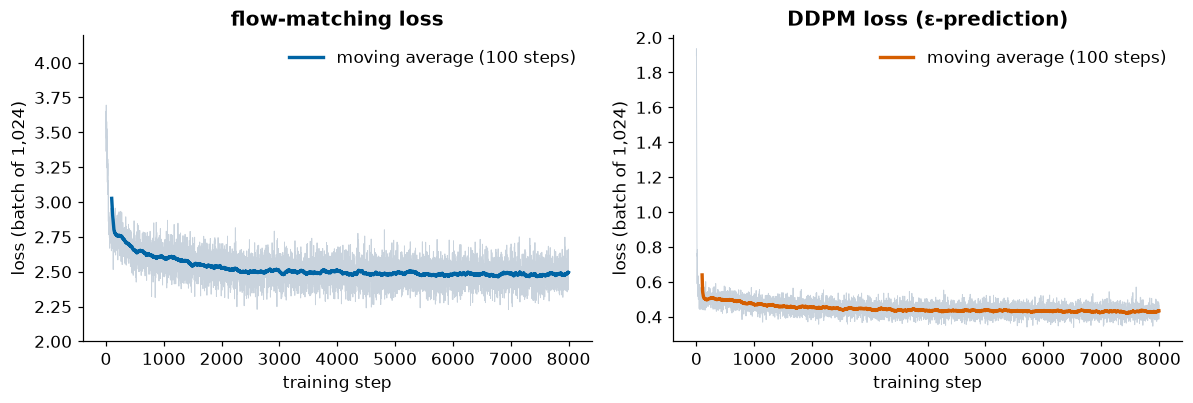

final flow-matching loss (moving average of the last 100 steps): 2.49
final DDPM loss:                                                0.43


In [8]:
k = 100
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, h, name, col in [(axs[0], h_fm, "flow-matching loss", C_FM), (axs[1], h_dd, "DDPM loss (ε-prediction)", C_DDPM)]:
    sm = np.convolve(h, np.ones(k) / k, mode="valid")
    ax.plot(h, color="#C9D3DD", lw=0.6)
    ax.plot(np.arange(k - 1, len(h)), sm, color=col, lw=2.2, label="moving average (100 steps)")
    ax.set(xlabel="training step", ylabel="loss (batch of 1,024)", title=name)
    ax.legend(loc="upper right")
axs[0].set_ylim(2.0, 4.2)
plt.tight_layout(); plt.show()
loss_end = np.convolve(h_fm, np.ones(k) / k, mode="valid")[-1]
print(f"final flow-matching loss (moving average of the last 100 steps): {loss_end:.2f}")
print(f"final DDPM loss:                                                {np.mean(h_dd[-100:]):.2f}")

**Why the loss plateaus far above zero.** The regression target $\boldsymbol\epsilon - \mathbf x_0$ is *random* given $(\mathbf x_t, t)$: many pairs $(\mathbf x_0, \boldsymbol\epsilon)$ pass through the same point. The best possible $\mathbf v_\theta$ is the conditional mean (the marginal velocity of Section 3), and the loss that remains is the conditional variance $\mathbb E\,\mathrm{Var}[\boldsymbol\epsilon - \mathbf x_0 \mid \mathbf x_t, t]$, a constant no model can remove. At the start, $\mathbb E\|\boldsymbol\epsilon - \mathbf x_0\|^2 \approx 2 + 2 = 4$ for unit-scale 2-D data; the model removes only the predictable part and levels off near 2.5. A flat loss therefore does not mean training failed, and the loss value says little about sample quality — **judge the model by its samples**.

## 6. Sampling

- **Flow matching:** draw $\mathbf x_1 \sim \mathcal N(\mathbf 0, \mathbf I)$ and integrate backward: $\mathbf x_{t-\Delta t} = \mathbf x_t - \Delta t\,\mathbf v_\theta(\mathbf x_t, t)$, $\Delta t = 1/N$. Deterministic; $N$ network evaluations (Heun's method: $2N$).
- **DDPM:** ancestral sampling, each step subtracts the predicted noise and adds fresh noise. With $N < T$ steps we use an evenly respaced subsequence of the 1000 timesteps (with the respaced β's).

In [9]:
@torch.no_grad()
def euler(net, x1, n_steps, c=None, w=0.0, keep=False, n_cls=2, method="euler"):
    """Integrate dx/dt = v_theta from t = 1 to t = 0 (Euler or Heun), optionally with classifier-free guidance."""
    x = torch.tensor(x1, dtype=torch.float32)
    path = [x.numpy().copy()]
    ts = np.linspace(1, 0, n_steps + 1)

    def v(x, t):
        tt = torch.full((len(x),), float(t))
        if c is None:
            return net(x, tt)
        out = net(x, tt, torch.full((len(x),), c, dtype=torch.long))
        if w:
            out = (1 + w) * out - w * net(x, tt, torch.full((len(x),), n_cls, dtype=torch.long))
        return out

    for t, t_next in zip(ts[:-1], ts[1:]):
        h = t_next - t                                            # h = -dt < 0: time runs backward
        v1 = v(x, t)
        if method == "heun":
            v2 = v(x + h * v1, t_next)                            # predictor, then average the two slopes
            x = x + h * 0.5 * (v1 + v2)
        else:
            x = x + h * v1
        path.append(x.numpy().copy())
    return (x.numpy(), np.array(path)) if keep else x.numpy()

@torch.no_grad()
def ddpm_sample(net, xT, n_steps=T_DDPM, seed=0, keep_at=()):
    """Ancestral DDPM sampling; n_steps < T uses an evenly respaced subsequence of timesteps."""
    g = torch.Generator().manual_seed(seed)
    ks = np.unique(np.round(np.linspace(0, T_DDPM, n_steps + 1)).astype(int))   # 0 = data
    x = torch.tensor(xT, dtype=torch.float32)
    snaps = {}
    for i in range(len(ks) - 1, 0, -1):
        k, kp = ks[i], ks[i - 1]
        a, ap = abar[k - 1], (abar[kp - 1] if kp > 0 else 1.0)
        b = 1 - a / ap
        eps = net(x, torch.full((len(x),), k / T_DDPM))
        mean = (x - b / np.sqrt(1 - a) * eps) / np.sqrt(1 - b)
        if kp > 0:
            x = mean + float(np.sqrt((1 - ap) / (1 - a) * b)) * torch.randn(x.shape, generator=g)
        else:
            x = mean
        for tk in keep_at:
            if abs(kp / T_DDPM - tk) < 0.5 / n_steps:
                snaps[tk] = x.numpy().copy()
    return x.numpy(), snaps

## 7. Evaluation: sample quality versus number of steps

**Sliced Wasserstein distance (SWD):** project both point sets onto 500 random directions, sort, and average the squared differences (Wasserstein-2 in 1-D), then take the square root. We compare 5,000 generated points with 5,000 held-out real points. The **floor** is the SWD between two independent real samples of the same size — no model can do better.

(evaluation took 25 s)
floor (two real samples): 0.0078

steps   flow matching (Euler)   DDPM (ancestral)
    1            0.870               1.265
    2            0.405               0.649
    4            0.196               0.358
    8            0.090               0.199
   16            0.049               0.105
   32            0.033               0.054
   64            0.027               0.027
  128            0.025               0.021
  256            0.025               0.022
 1000            0.025               0.022


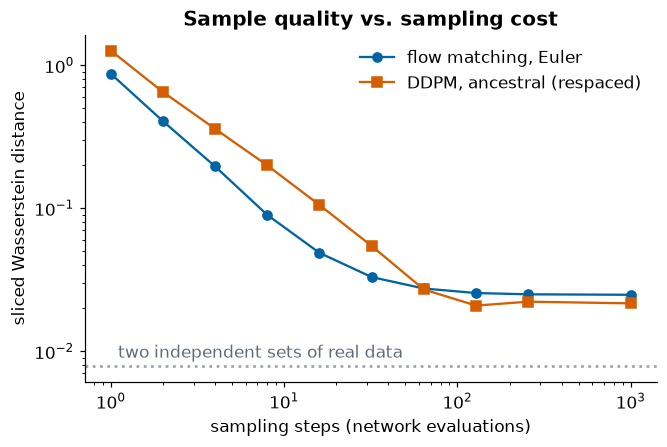

In [10]:
def swd(A, B, n_proj=500, seed=0):
    """Sliced Wasserstein-2 distance between equal-size point sets (random 1-D projections, sorted matching)."""
    rng = np.random.default_rng(seed)
    th = rng.normal(size=(n_proj, 2))
    th /= np.linalg.norm(th, axis=1, keepdims=True)
    pa, pb = np.sort(A @ th.T, 0), np.sort(B @ th.T, 0)
    return float(np.sqrt(((pa - pb) ** 2).mean()))

N = 5000
ref, ref2 = moons(N, seed=123), moons(N, seed=456)
x1 = np.random.default_rng(7).normal(size=(N, 2)).astype(np.float32)
steps = [1, 2, 4, 8, 16, 32, 64, 128, 256, 1000]
t0 = time.time()
sw_fm = {s: swd(euler(fm, x1, s), ref) for s in steps}
sw_dd = {s: swd(ddpm_sample(dd, x1, s)[0], ref) for s in steps}
floor = swd(ref2, ref)
print(f"(evaluation took {time.time() - t0:.0f} s)")
print(f"floor (two real samples): {floor:.4f}\n")
print("steps   flow matching (Euler)   DDPM (ancestral)")
for s in steps:
    print(f"{s:5d}   {sw_fm[s]:14.3f}          {sw_dd[s]:10.3f}")

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(steps, [sw_fm[s] for s in steps], "o-", color=C_FM, label="flow matching, Euler")
ax.plot(steps, [sw_dd[s] for s in steps], "s-", color=C_DDPM, label="DDPM, ancestral (respaced)")
ax.axhline(floor, color=GREY, ls=":", lw=1.8)
ax.text(1.1, floor * 1.15, "two independent sets of real data", color="#5F6B7A", fontsize=11)
ax.set(xscale="log", yscale="log", xlabel="sampling steps (network evaluations)", ylabel="sliced Wasserstein distance",
       title="Sample quality vs. sampling cost")
ax.legend(); plt.tight_layout(); plt.show()

**Lecture values** (8,000 steps, trained on Apple MPS): floor 0.0078; flow matching 0.091 / 0.035 / 0.026 at 8 / 32 / 1000 steps; DDPM 0.201 / 0.055 / 0.022. This notebook trains on the CPU, so the random streams (and therefore the trained networks) differ slightly from the lecture build. Our run: floor 0.0078; flow matching 0.090 / 0.033 / 0.025; DDPM 0.199 / 0.054 / 0.022 — within 0.002 of the slides. The pattern: flow matching is much better with few steps (its paths are closer to straight); with ≥ 64 steps both are close, and neither reaches the real-data floor — the remaining gap is the error of a small MLP trained for 8,000 steps. One toy data set and one training run: a demonstration, not a benchmark.

## 8. Visualization

### Trajectories and snapshots
Grey lines follow 200 samples from noise (orange, $t = 1$) to data (blue, $t = 0$) with 100 Euler steps. The conditional paths used in training are straight and cross each other; the learned (marginal) flow is curved and its paths never cross — an ODE cannot send one point to two places.

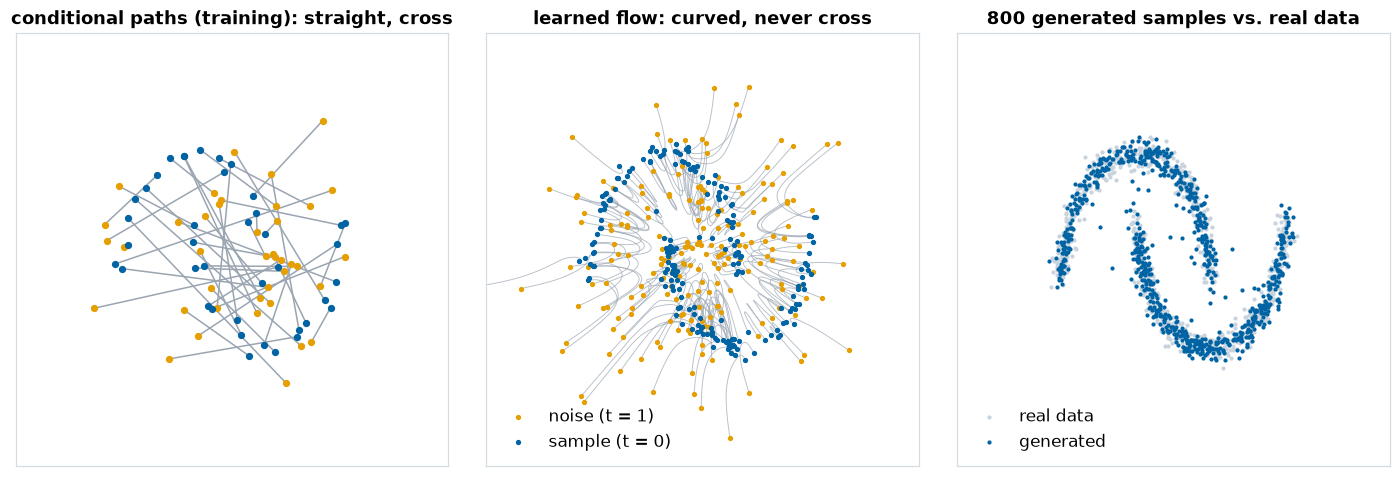

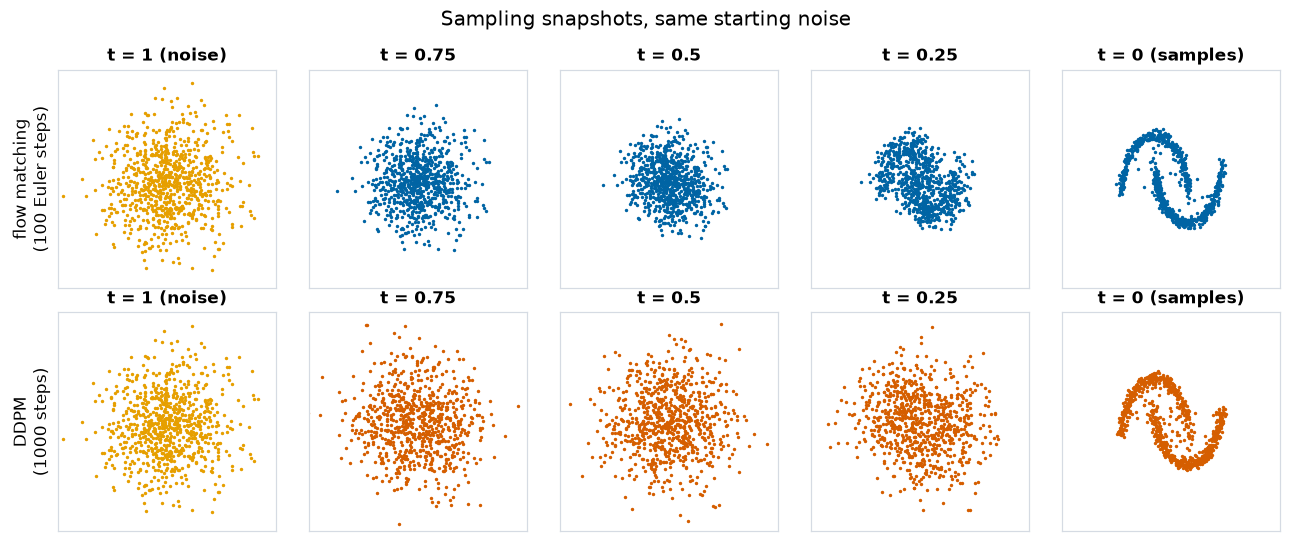

In [11]:
xs_fm, P = euler(fm, x1[:800], 100, keep=True)
E40, X40 = np.random.default_rng(11).normal(size=(40, 2)), moons(40, seed=8)
fig, axs = plt.subplots(1, 3, figsize=(13, 4.3))
for a, b in zip(X40, E40):
    axs[0].plot([a[0], b[0]], [a[1], b[1]], color=GREY, lw=1)
axs[0].scatter(*E40.T, s=14, color=C_NOISE, zorder=3); axs[0].scatter(*X40.T, s=14, color=C_DATA, zorder=3)
axs[0].set_title("conditional paths (training): straight, cross", fontsize=12)
for i in range(200):
    axs[1].plot(P[:, i, 0], P[:, i, 1], color=GREY, lw=0.6, alpha=0.7)
axs[1].scatter(*P[0, :200].T, s=6, color=C_NOISE, zorder=3, label="noise (t = 1)")
axs[1].scatter(*P[-1, :200].T, s=6, color=C_DATA, zorder=3, label="sample (t = 0)")
axs[1].set_title("learned flow: curved, never cross", fontsize=12); axs[1].legend(loc="lower left")
axs[2].scatter(*ref[:800].T, s=3, color="#C9D3DD", label="real data")
axs[2].scatter(*xs_fm.T, s=3, color=C_FM, label="generated")
axs[2].set_title("800 generated samples vs. real data", fontsize=12); axs[2].legend(loc="lower left")
for a in axs:
    clean(a, 3.0)
plt.tight_layout(); plt.show()

_, dsnap = ddpm_sample(dd, x1[:800], 1000, keep_at=(0.75, 0.5, 0.25))
dd_final = ddpm_sample(dd, x1[:800], 1000)[0]
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
labels = ["t = 1 (noise)", "t = 0.75", "t = 0.5", "t = 0.25", "t = 0 (samples)"]
for j, (Xf, Xd) in enumerate(zip([P[0], P[25], P[50], P[75], P[100]],
                                 [x1[:800], dsnap[0.75], dsnap[0.5], dsnap[0.25], dd_final])):
    for i, X in enumerate([Xf, Xd]):
        axs[i, j].scatter(*X.T, s=1.5, color=C_NOISE if j == 0 else (C_FM, C_DDPM)[i])
        axs[i, j].set_title(labels[j], fontsize=11); clean(axs[i, j], 3.4)
axs[0, 0].set_ylabel("flow matching\n(100 Euler steps)", fontsize=11); axs[1, 0].set_ylabel("DDPM\n(1000 steps)", fontsize=11)
fig.suptitle("Sampling snapshots, same starting noise"); plt.tight_layout(); plt.show()

### The learned velocity field changes with time
Arrows show the direction of motion during sampling, $-\mathbf v_\theta(\mathbf x, t)$, on a 15 × 15 grid; dots are the samples at that time. Early ($t \approx 1$) the flow is gentle and almost global; late ($t \approx 0.1$) it pulls sharply onto the two moons.

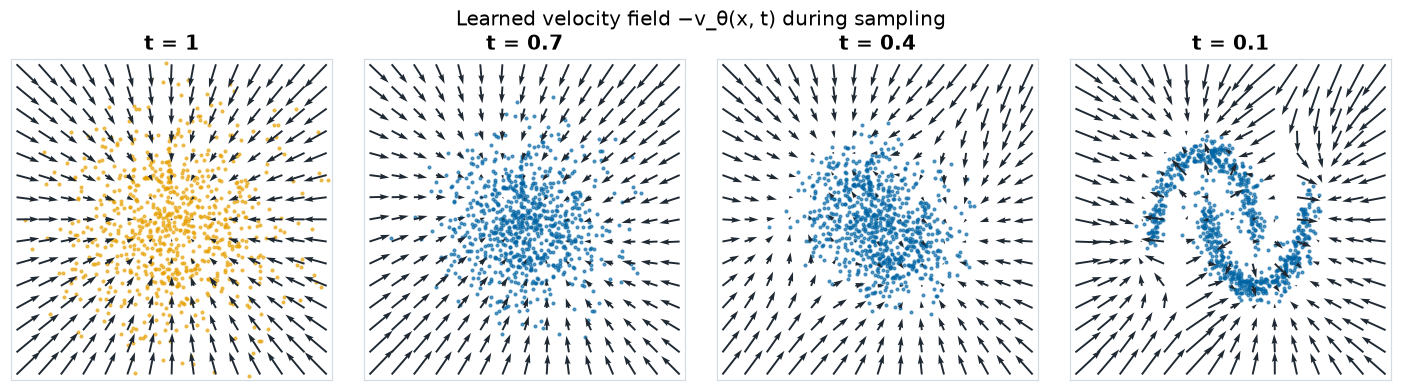

In [12]:
g = np.linspace(-2.8, 2.8, 15)
GX, GY = np.meshgrid(g, g)
G = torch.tensor(np.c_[GX.ravel(), GY.ravel()], dtype=torch.float32)
fig, axs = plt.subplots(1, 4, figsize=(13, 3.6))
for a, t, idx in zip(axs, [1.0, 0.7, 0.4, 0.1], [0, 30, 60, 90]):
    with torch.no_grad():
        v = -fm(G, torch.full((len(G),), t)).numpy()
    a.scatter(*P[idx].T, s=3, color=C_NOISE if t == 1 else C_DATA, alpha=0.6, zorder=1)
    a.quiver(G[:, 0], G[:, 1], v[:, 0], v[:, 1], color="#1F2933", scale=40, width=0.006, zorder=2)
    a.set_title(f"t = {t:g}", fontsize=13); clean(a, 2.9)
fig.suptitle("Learned velocity field −v_θ(x, t) during sampling"); plt.tight_layout(); plt.show()

### Fewer steps give cruder samples
Same trained networks, same starting noise; only the number of sampling steps changes.

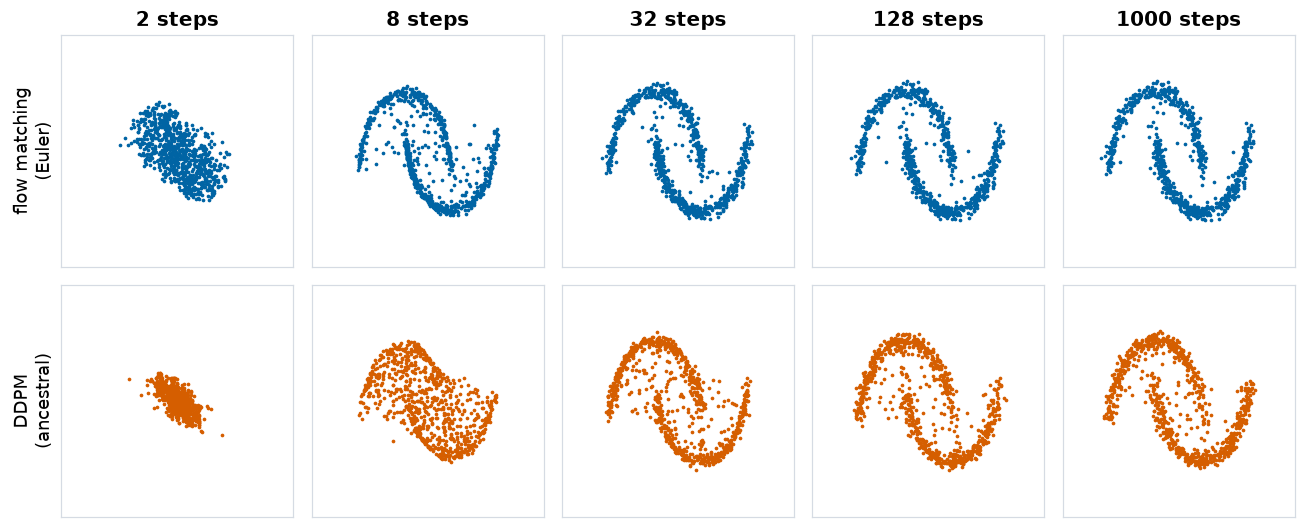

In [13]:
ks_grid = [2, 8, 32, 128, 1000]
fig, axs = plt.subplots(2, len(ks_grid), figsize=(12, 5))
for j, s in enumerate(ks_grid):
    axs[0, j].scatter(*euler(fm, x1[:800], s).T, s=2, color=C_FM)
    axs[1, j].scatter(*ddpm_sample(dd, x1[:800], s)[0].T, s=2, color=C_DDPM)
    axs[0, j].set_title(f"{s} steps", fontsize=13)
    for a in axs[:, j]:
        clean(a, 2.6)
axs[0, 0].set_ylabel("flow matching\n(Euler)", fontsize=12); axs[1, 0].set_ylabel("DDPM\n(ancestral)", fontsize=12)
plt.tight_layout(); plt.show()

With 2 steps both samplers collapse toward the average (the first Euler step from $t = 1$ lands on $\mathbb E[\mathbf x_0 \mid \mathbf x_1] \approx$ the data mean, exactly as in the 1-D example). Flow matching recovers the moons with fewer steps on this problem because its paths are closer to straight.

## 9. Optional: class-conditional flow matching on BloodMNIST (GPU)

The same algorithm on images: $\mathbf x_0$ is a $3\times28\times28$ blood-cell image scaled to $[-1, 1]$, the velocity network is a small U-Net that also receives $t$ and the cell class $c$, and 10% of the labels are replaced by a "no class" token so one network learns both $\mathbf v_\theta(\mathbf x, t, c)$ and $\mathbf v_\theta(\mathbf x, t, \varnothing)$. At sampling time, **classifier-free guidance** uses $(1+w)\,\mathbf v_\theta(\mathbf x, t, c) - w\,\mathbf v_\theta(\mathbf x, t, \varnothing)$. This section is not part of the lecture's numbers and is skipped on a CPU (it would take tens of minutes); on a CUDA GPU it takes about 4 minutes (U-Net with 1.0 M parameters, 8,000 steps of batch 128; longer on Apple MPS). Set `RUN_BLOOD = True` to force it.

U-Net parameters: 1,015,939


trained 8000 steps in 242 s, final loss 0.109


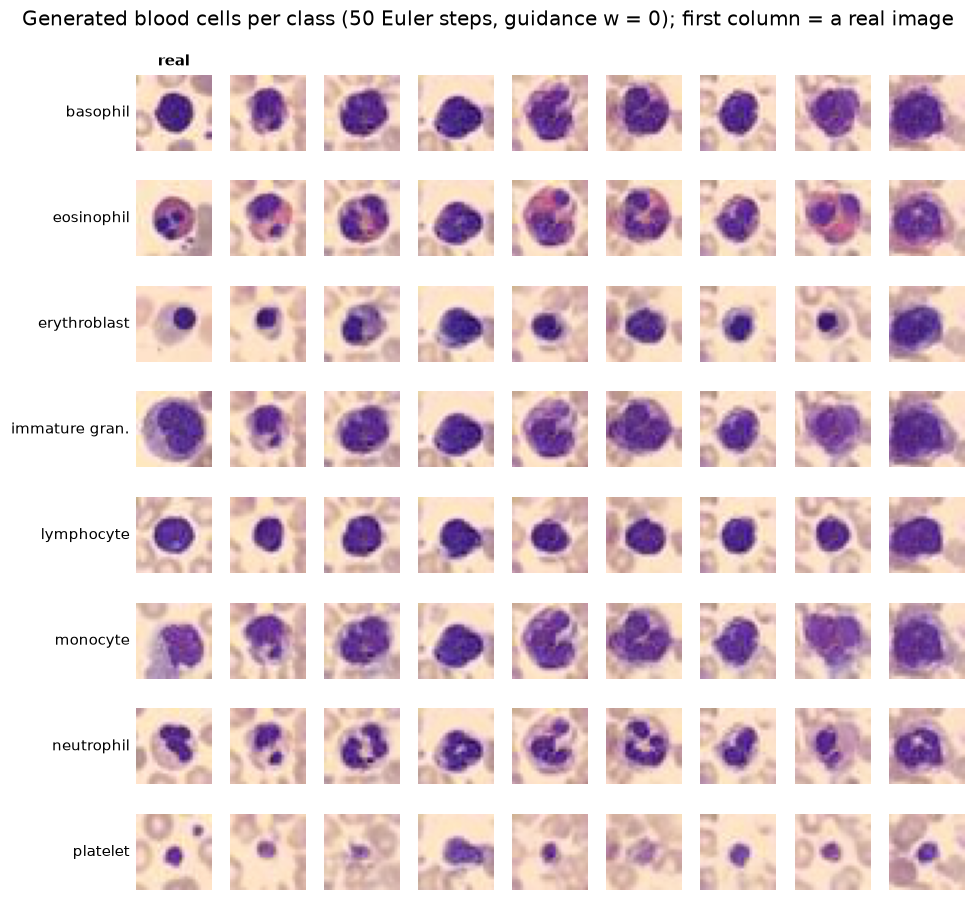

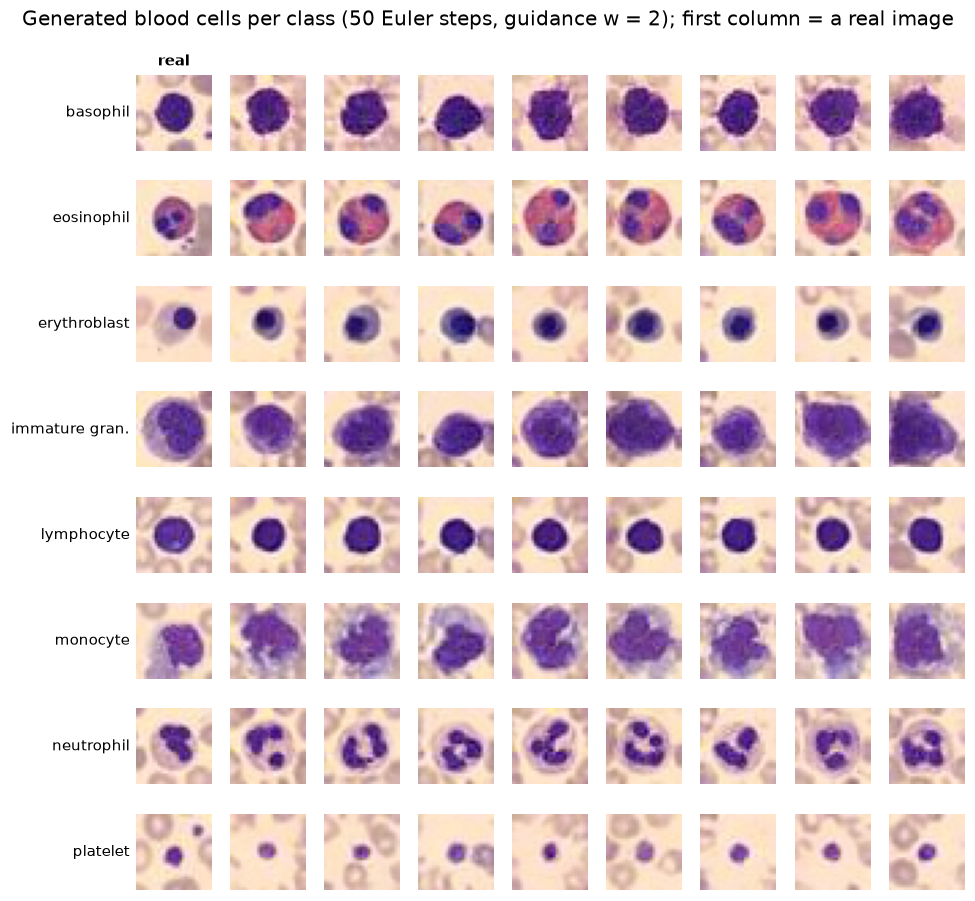

In [14]:
if RUN_BLOOD:
    from medmnist import BloodMNIST
    CLASSES = ["basophil", "eosinophil", "erythroblast", "immature gran.", "lymphocyte", "monocyte", "neutrophil", "platelet"]
    ds = BloodMNIST(split="train", download=True, root=str(DATA))
    Xb = torch.tensor(ds.imgs).permute(0, 3, 1, 2).float() / 127.5 - 1      # N x 3 x 28 x 28 in [-1, 1]
    yb = torch.tensor(ds.labels[:, 0]).long()

    class Block(nn.Module):
        def __init__(self, c_in, c_out, d_emb):
            super().__init__()
            self.c1, self.c2 = nn.Conv2d(c_in, c_out, 3, padding=1), nn.Conv2d(c_out, c_out, 3, padding=1)
            self.n1, self.n2 = nn.GroupNorm(8, c_out), nn.GroupNorm(8, c_out)
            self.emb = nn.Linear(d_emb, c_out)
            self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

        def forward(self, x, e):
            h = nn.functional.silu(self.n1(self.c1(x)))
            h = h + self.emb(e)[:, :, None, None]                     # inject time + class
            h = nn.functional.silu(self.n2(self.c2(h)))
            return h + self.skip(x)

    class UNet(nn.Module):
        """28 -> 14 -> 7 U-Net with time (sinusoidal) and class embeddings; output = velocity image."""
        def __init__(self, n_cls=8, ch=64, d_emb=128):
            super().__init__()
            self.register_buffer("freqs", torch.exp(torch.linspace(0, np.log(1000), d_emb // 2)), persistent=False)
            self.cls = nn.Embedding(n_cls + 1, d_emb)
            self.mlp = nn.Sequential(nn.Linear(d_emb, d_emb), nn.SiLU(), nn.Linear(d_emb, d_emb))
            self.inp = nn.Conv2d(3, ch, 3, padding=1)
            self.d1, self.d2 = Block(ch, ch, d_emb), Block(ch, 2 * ch, d_emb)
            self.mid = Block(2 * ch, 2 * ch, d_emb)
            self.u2, self.u1 = Block(4 * ch, ch, d_emb), Block(2 * ch, ch, d_emb)
            self.out = nn.Conv2d(ch, 3, 3, padding=1)

        def forward(self, x, t, c):
            tt = t[:, None] * self.freqs
            e = self.mlp(torch.cat([torch.sin(tt), torch.cos(tt)], 1)) + self.cls(c)
            h0 = self.d1(self.inp(x), e)                              # 64 x 28 x 28
            h1 = self.d2(nn.functional.avg_pool2d(h0, 2), e)          # 128 x 14 x 14
            h = self.mid(nn.functional.avg_pool2d(h1, 2), e)          # 128 x 7 x 7
            h = self.u2(torch.cat([nn.functional.interpolate(h, scale_factor=2), h1], 1), e)
            h = self.u1(torch.cat([nn.functional.interpolate(h, scale_factor=2), h0], 1), e)
            return self.out(h)

    torch.manual_seed(0)
    unet = UNet().to(dev)
    print(f"U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}")
    IMG_STEPS, IMG_BATCH = 8000, 128
    opt = torch.optim.Adam(unet.parameters(), lr=2e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, IMG_STEPS)
    Xb_d, yb_d = Xb.to(dev), yb.to(dev)
    t0, hist_img = time.time(), []
    for it in range(IMG_STEPS):
        idx = torch.randint(0, len(Xb_d), (IMG_BATCH,), device=dev)
        x0, c = Xb_d[idx], yb_d[idx].clone()
        c[torch.rand(IMG_BATCH, device=dev) < 0.1] = 8                # label dropout -> unconditional model
        eps = torch.randn_like(x0)
        t = torch.rand(IMG_BATCH, device=dev)
        xt = (1 - t[:, None, None, None]) * x0 + t[:, None, None, None] * eps
        loss = ((unet(xt, t, c) - (eps - x0)) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        hist_img.append(loss.item())
    print(f"trained {IMG_STEPS} steps in {time.time() - t0:.0f} s, final loss {np.mean(hist_img[-200:]):.3f}")

    @torch.no_grad()
    def sample_images(c, n=8, n_steps=50, w=2.0, seed=0):
        g = torch.Generator(device="cpu").manual_seed(seed)
        x = torch.randn(n, 3, 28, 28, generator=g).to(dev)
        cc, cu = torch.full((n,), c, device=dev), torch.full((n,), 8, device=dev)
        ts = torch.linspace(1, 0, n_steps + 1)
        for t, tn in zip(ts[:-1], ts[1:]):
            tt = torch.full((n,), float(t), device=dev)
            v = (1 + w) * unet(x, tt, cc) - w * unet(x, tt, cu)
            x = x + float(tn - t) * v
        return ((x.clamp(-1, 1) + 1) / 2).permute(0, 2, 3, 1).cpu().numpy()

    unet.eval()
    for w in [0.0, 2.0]:
        fig, axs = plt.subplots(8, 9, figsize=(9, 8.4))
        for c in range(8):
            real = Xb[yb == c][0].permute(1, 2, 0).numpy() / 2 + 0.5
            axs[c, 0].imshow(real); axs[c, 0].set_ylabel(CLASSES[c], rotation=0, ha="right", va="center", fontsize=10)
            for j, im in enumerate(sample_images(c, w=w)):
                axs[c, j + 1].imshow(im)
        for a in axs.ravel():
            a.set_xticks([]); a.set_yticks([])
            for sp in a.spines.values():
                sp.set_visible(False)
        axs[0, 0].set_title("real", fontsize=10)
        fig.suptitle(f"Generated blood cells per class (50 Euler steps, guidance w = {w:g}); first column = a real image")
        plt.tight_layout(); plt.show()
else:
    print("Skipped: no GPU found (set RUN_BLOOD = True to run on the CPU anyway; expect tens of minutes).")

## 10. Biological interpretation

- **What was learned.** Neither model ever saw a formula for the moons. Both learned, by regression on (noisy point, time) pairs, a field that moves noise onto the data distribution. The same recipe with $\mathbf x_0$ = 3-D coordinates of a protein backbone is RFdiffusion (Watson et al., *Nature* 2023); with atoms and bonds it is equivariant molecular diffusion (Hoogeboom et al., ICML 2022); with all heavy-atom coordinates conditioned on a sequence it is AlphaFold 3's structure module (Abramson et al., *Nature* 2024, → L20).
- **Sampling cost is a real constraint.** Every sample needs $N$ network evaluations. For protein design and structure prediction the network is large, so solvers that need fewer steps (straighter paths, Heun, distillation) matter in practice.
- **A realistic sample is not a correct one.** SWD, like FID for images, measures distributional similarity, not biological validity. Generated proteins must be checked (folding, experiments); synthetic medical images can contain plausible but wrong anatomy, and diffusion models trained on small cohorts can memorize and reproduce patient images (Dar et al., *Nat. Biomed. Eng.* 2025). Treat synthetic data from small patient cohorts as potentially identifiable.
- **Guidance trades diversity for fidelity.** With classifier-free guidance ($w > 0$), class-conditional samples look more typical of their class but vary less — useful for data augmentation of rare cell types, but a biased picture of the real variability.

In [15]:
print(f"total runtime: {time.time() - T0:.0f} s")

total runtime: 403 s


## Try it yourself

1. **Use the DDPM path instead of the linear one.** Set `PATH = "ddpm"` in Section 5 and re-run from there (only the flow-matching model changes). How do the SWD values at 8, 32 and 1000 Euler steps change? The loss values are not comparable across paths (the velocity targets have different scales), so compare samples. Use the coefficient plot of Section 2 to reason about where along $t$ each path changes fastest, and how that interacts with equal-size Euler steps.
2. **Sample with Heun's method: steps saved?** `euler(fm, x1, n, method="heun")` uses two network evaluations per step. Compare `swd(euler(fm, x1, 4, method="heun"), ref)` with Euler at 8 steps, and Heun 16 with Euler 32 (equal cost). When does the second-order method pay off?
3. **Remove the time input t: what breaks?** Set `USE_TIME = False` in Section 4 and re-run from there. The network now has to output one velocity per location for all $t$. What do the samples look like, and what happens to the final loss? (Think about the first step from $t = 1$ and the last step near $t = 0$.)
4. **Another shape.** Replace `moons` by a spiral (e.g. $r = \theta/3\pi$, $\theta \sim U(0.5\pi, 3\pi)$, plus noise, rescaled to unit spread). Does the model need more training steps or sampling steps for the longer, thinner curve?
5. **(CS284A) Classifier-free guidance on the moons.** Train `cf, _ = train("fm", n_cls=2, seed=1)` (labels 0 = upper, 1 = lower moon, 20% label dropout), then sample with `euler(cf, x1[:800], 64, c=1, w=0.0)` and `w=3.0`. Measure the fraction of samples on the requested moon (e.g. with a 5-NN classifier trained on labelled `moons(4000, seed=99, labels=True)`) and their median distance to the nearest real point. What does guidance buy, and what does it cost? Also show that for the linear path $\mathbf v = (\mathbb E[\boldsymbol\epsilon\mid\mathbf x_t] - \mathbf x_t)/(1-t)$ and relate it to the score $\nabla\log p_t(\mathbf x) = -\mathbb E[\boldsymbol\epsilon\mid\mathbf x_t]/t$; check both numerically with `v_marginal_1d` and `density_1d` at $x = 0.5$, $t = 0.5$, $s_0 = 0.08$.